# ISLib — Instance Selection Library

**ISLib** helps identify optimal training periods for regression models through two complementary techniques:

| # | Method | Description |
|---|--------|-------------|
| 1 | **Cluster Analysis** | K-Means clustering to identify operational regimes and select the most informative ones. |
| 2 | **Sliding Window Analysis** | Determines the ideal training-window size that minimizes prediction error. |
| 3 | **Full Analysis** | End-to-end pipeline combining both methods above. |

This notebook demonstrates all three entry points of the library.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from islib import InstanceSelectionLib

## 1 — Load and Inspect the Dataset

The sample dataset (`Dataset.csv`) contains time-indexed numeric features. The first column is a datetime index; the remaining columns are process variables.

In [2]:
df = pd.read_csv("Dataset.csv", sep=";", parse_dates=["data_datetime"])
df["data_datetime"] = df["data_datetime"].dt.tz_localize(None)
df = df.set_index("data_datetime").sort_index()

print(f"Shape  : {df.shape}")
print(f"Period : {df.index.min()} → {df.index.max()}")
df.head()

Shape  : (30775, 6)
Period : 2022-08-17 08:04:00 → 2023-07-15 17:10:00


,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
data_datetime,,,,,,
2022-08-17 08:04:00,100.0,22.850000,12.528194,101.206261,23.509687,240.219768
2022-08-17 08:14:00,100.0,22.837500,925.574768,101.496750,23.509676,240.485595
2022-08-17 08:24:00,100.0,22.819385,1038.866330,101.400000,23.509672,241.415646
2022-08-17 08:34:00,100.0,22.818060,950.098700,101.400000,23.443645,241.234111
2022-08-17 08:44:00,100.0,22.811836,970.249756,101.400000,23.491274,241.423122


## 2 — Full Analysis (Clustering + Sliding Window)

`full_analysis` runs the complete pipeline:
1. Preprocessing  
2. K-Means cluster optimization  
3. Per-cluster regression & ranking  
4. Sliding-window regression on the selected clusters  
5. Report generation

**Returns** → `(df_processed, sorted_clusters, test_errors, min_error_idx, df_results, df_optimized, results_markdown)`

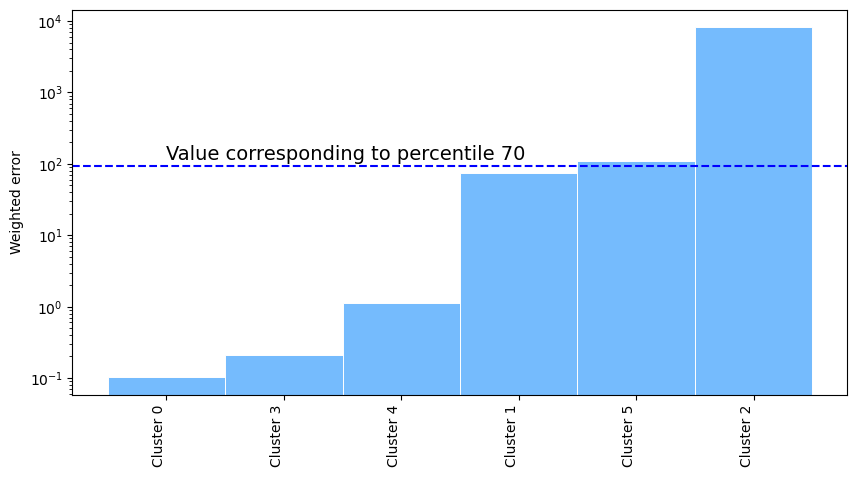

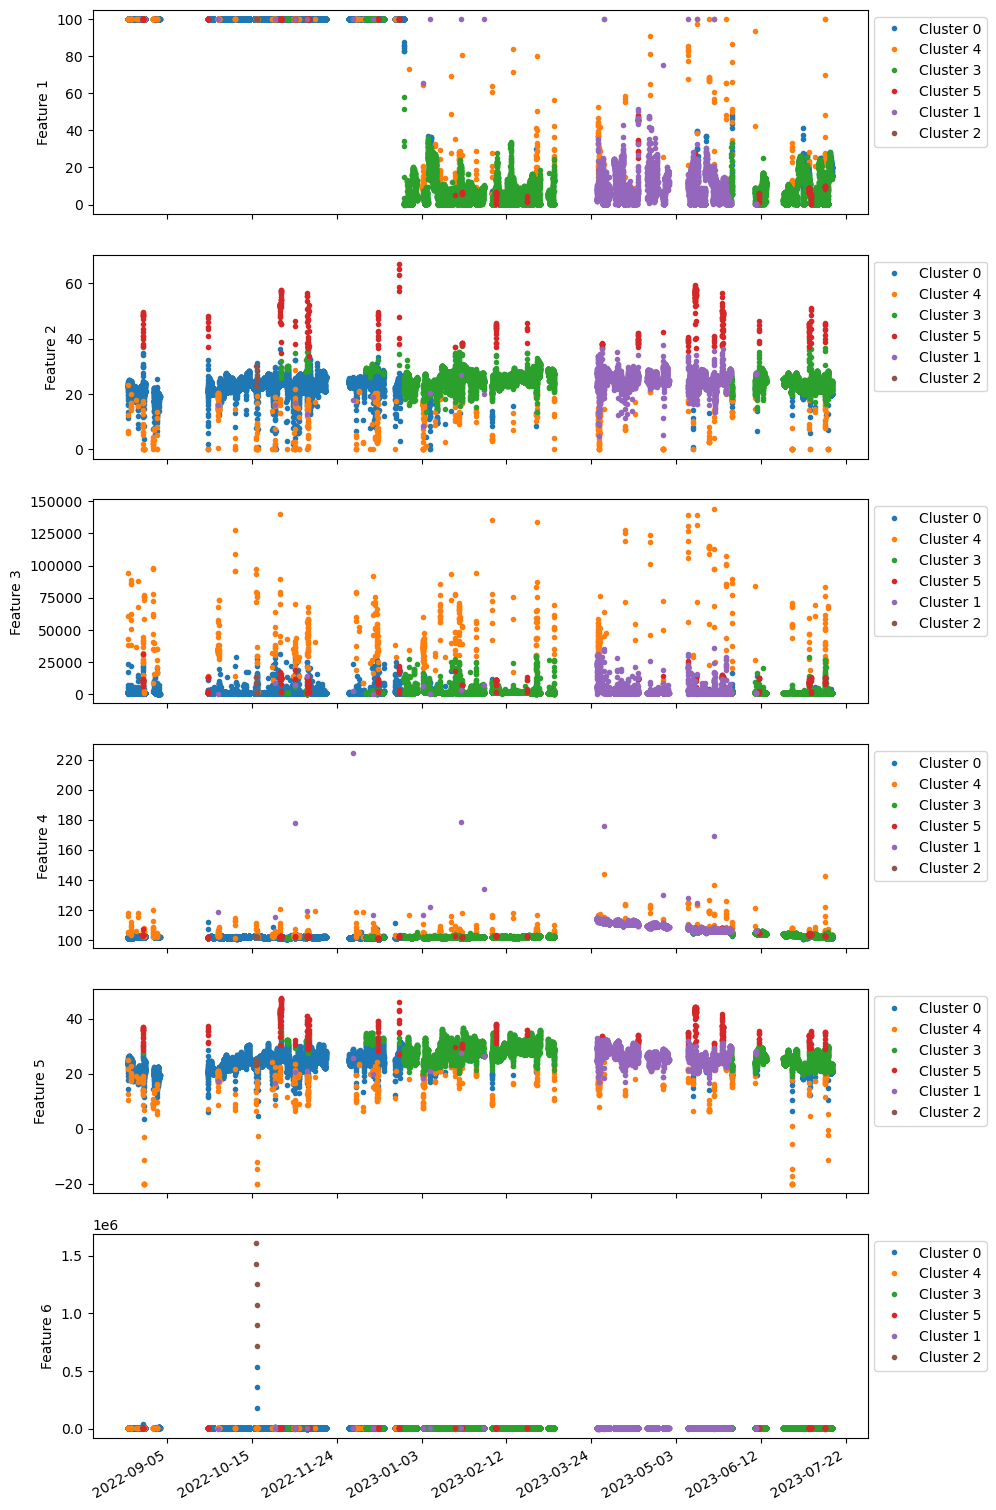

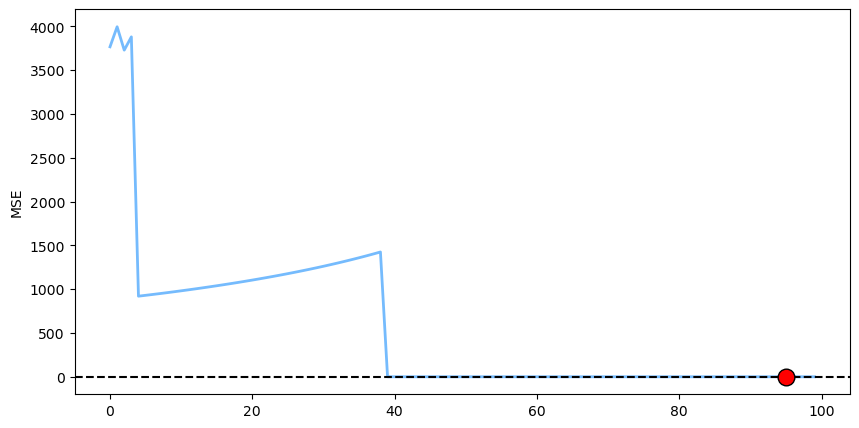

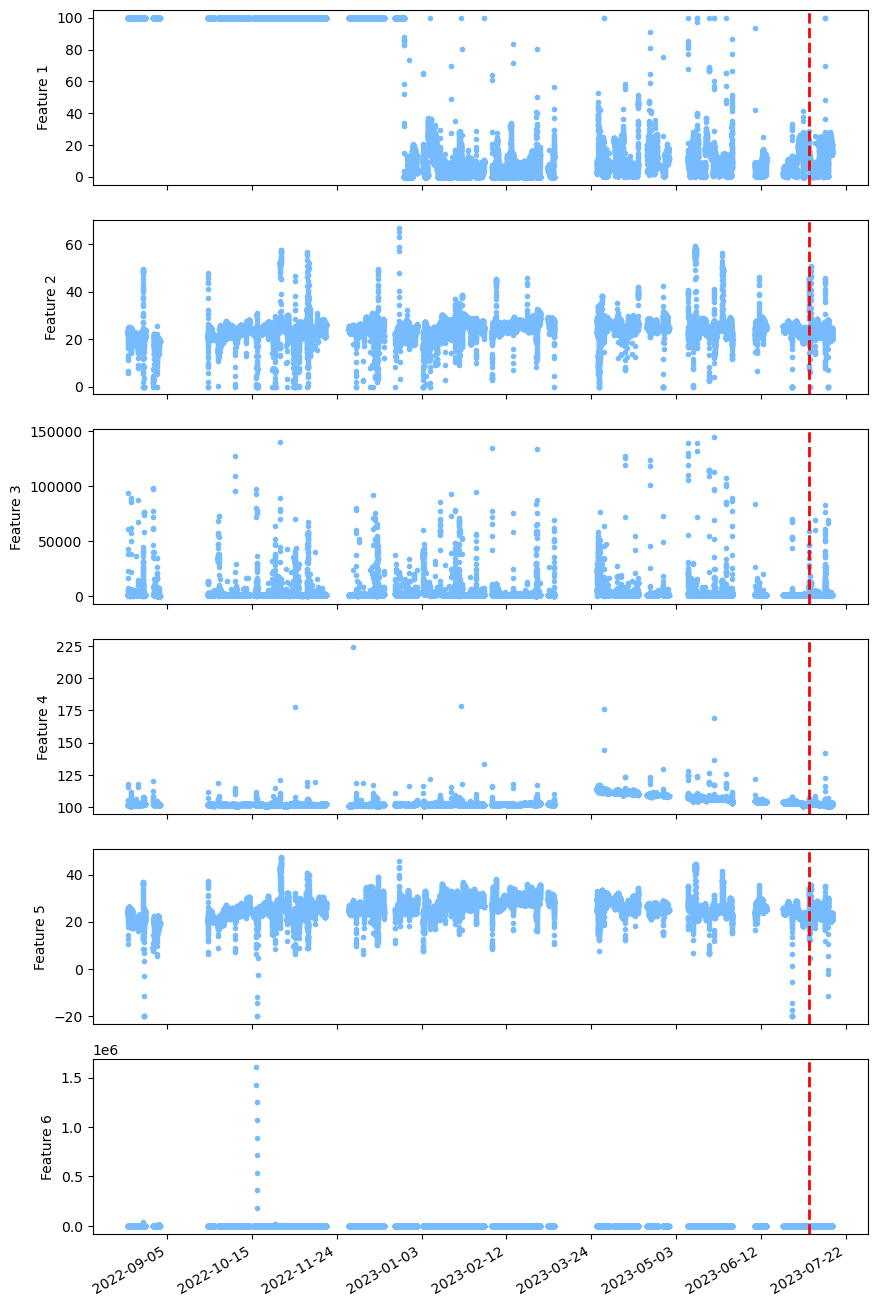

Clusters found        : 6
Best cluster          : (0, 0.10221780105919642)
Sliding-window points : 100
Min error index       : 29214
Optimized dataset     : (28881, 6)  (6.2% reduction)


In [3]:
islib_full = InstanceSelectionLib(
    max_clusters=25,
    min_window=30,
    resolution=100,
    tolerance=0.1,
    percentile_limit=70,
    show_figures=True,
)

(
    df_processed,
    sorted_clusters,
    test_errors,
    min_error_idx,
    df_results,
    df_optimized,
    report_md,
) = islib_full.full_analysis(df)

# --- Summary ---
n_clusters = len(sorted_clusters) if sorted_clusters else 0
print(f"Clusters found        : {n_clusters}")
print(f"Best cluster          : {sorted_clusters[0] if sorted_clusters else 'N/A'}")
print(f"Sliding-window points : {len(test_errors) if test_errors else 0}")
print(f"Min error index       : {min_error_idx}")
if df_optimized is not None:
    reduction = (1 - len(df_optimized) / len(df)) * 100
    print(f"Optimized dataset     : {df_optimized.shape}  ({reduction:.1f}% reduction)")

## 3 — Cluster Analysis Only

`cluster_analysis` runs only the clustering part of the pipeline (no sliding window).

**Returns** → `(df_clustered, sorted_clusters, df_periods, cluster_markdown)`

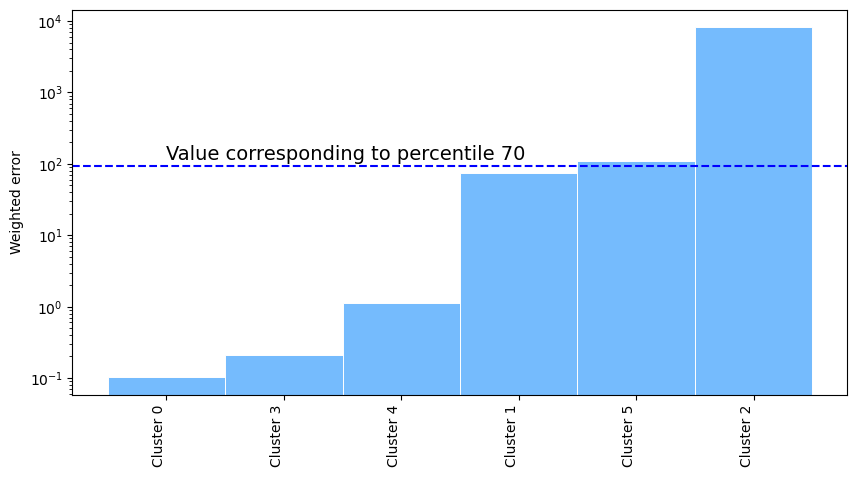

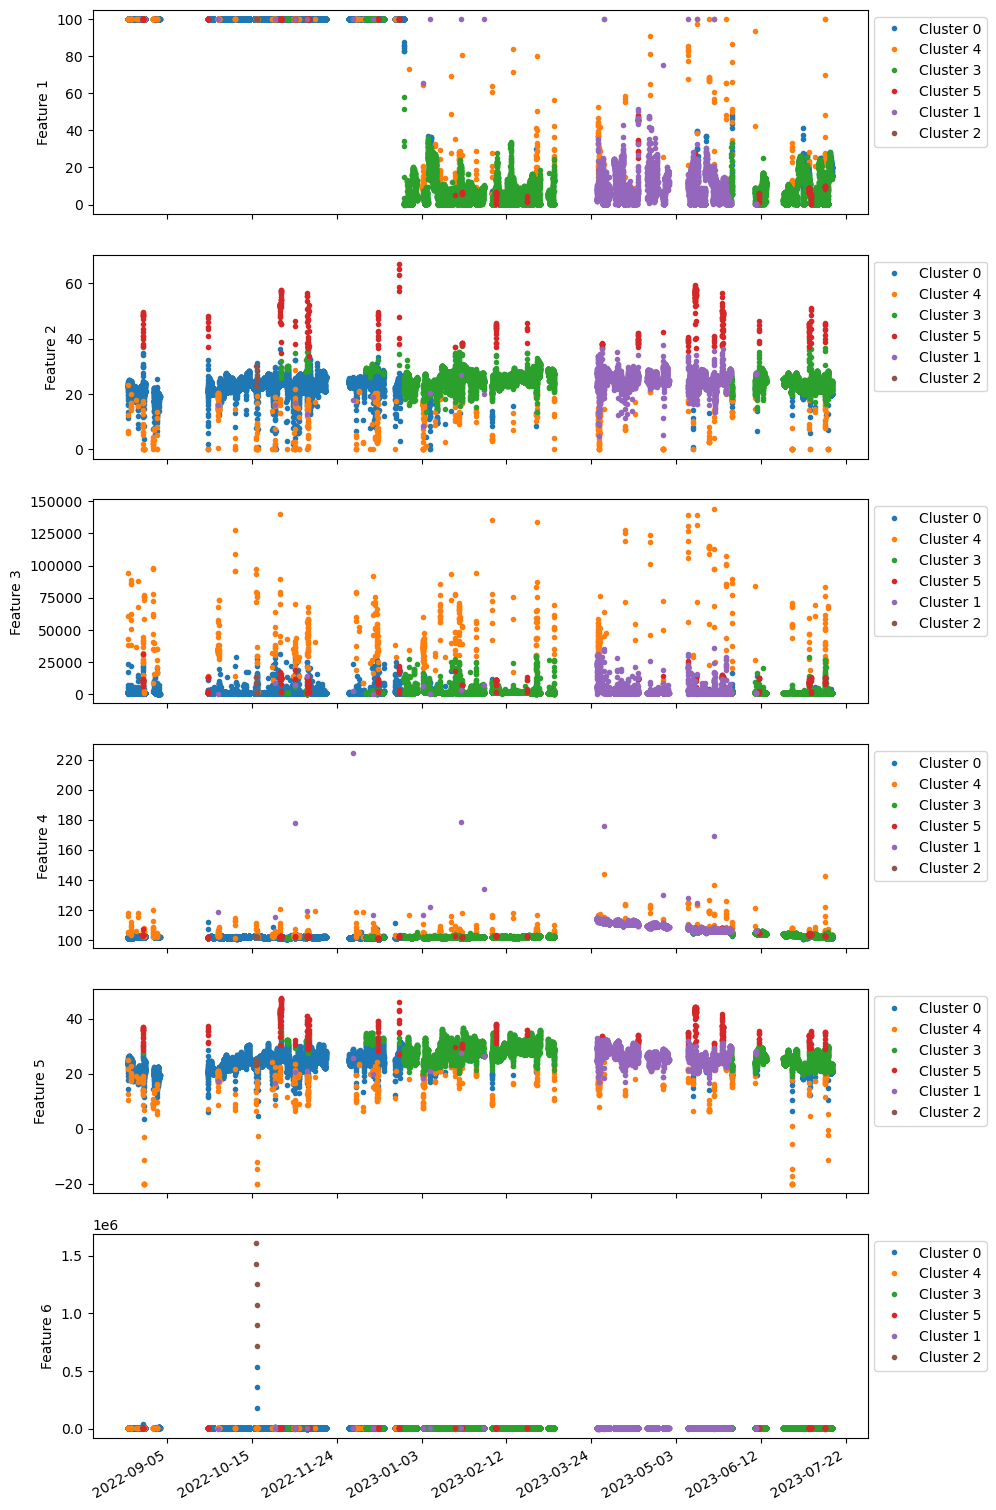

Cluster distribution:
Clusters
0    11835
1     5908
2        6
3    12070
4      615
5      341

Selected training periods (343):
       Initial date          Final date  Cluster
2022-08-17 08:04:00 2022-08-17 12:44:00      0.0
2022-08-17 12:54:00 2022-08-17 13:14:00      4.0
2022-08-17 13:24:00 2022-08-17 15:14:00      0.0
2022-08-17 15:34:00 2022-08-18 16:34:00      0.0
2022-08-18 16:54:00 2022-08-19 00:24:00      0.0
2022-08-19 00:34:00 2022-08-19 01:24:00      4.0
2022-08-19 01:34:00 2022-08-21 07:04:00      0.0
2022-08-21 07:24:00 2022-08-22 05:14:00      0.0
2022-08-22 05:24:00 2022-08-22 05:32:00      4.0
2022-08-22 05:42:00 2022-08-24 10:12:00      0.0
2022-08-24 10:22:00 2022-08-24 10:32:00      4.0
2022-08-24 10:42:00 2022-08-24 11:02:00      0.0
2022-08-24 11:12:00 2022-08-24 11:22:00      4.0
2022-08-24 11:32:00 2022-08-24 11:52:00      0.0
2022-08-24 12:02:00 2022-08-24 12:32:00      4.0
2022-08-24 12:52:00 2022-08-24 13:42:00      4.0
2022-08-24 13:52:00 2022-08-24 14:32

In [4]:
islib_cluster = InstanceSelectionLib(
    max_clusters=25,
    percentile_limit=70,
    show_figures=True,
)

df_clustered, sorted_clusters_c, df_periods, cluster_md = islib_cluster.cluster_analysis(df)

# --- Summary ---
if df_clustered is not None and "Clusters" in df_clustered.columns:
    print("Cluster distribution:")
    print(df_clustered["Clusters"].value_counts().sort_index().to_string())

if df_periods is not None and not df_periods.empty:
    print(f"\nSelected training periods ({len(df_periods)}):")
    print(df_periods.to_string(index=False))

## 4 — Sliding Window Analysis Only

`window_analysis` runs only the sliding-window regression step. It can receive either raw data or a previously clustered/filtered dataset.

**Returns** → `(test_errors, min_error_idx, spike_idxs, df_optimized, window_markdown)`

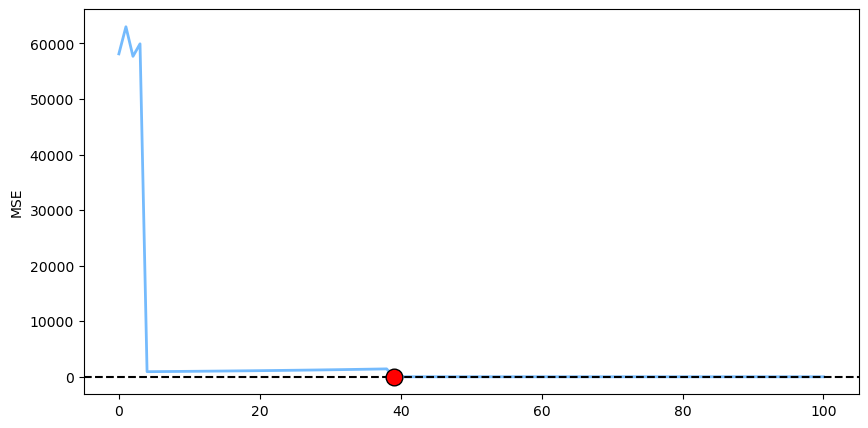

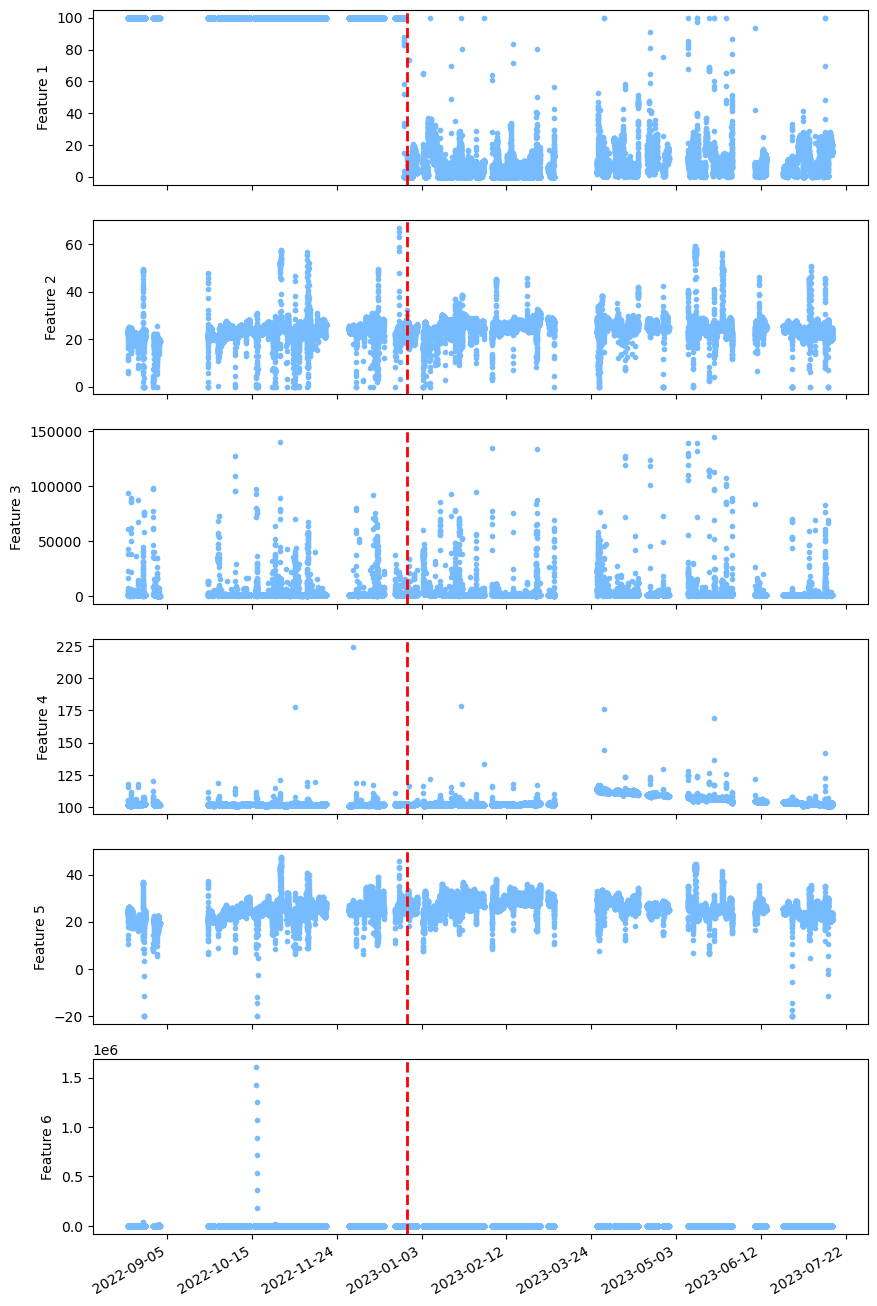

Window evaluation points : 101
Min error               : 0.028612  (index 12003)
Max error               : 63001.067667
Mean error              : 2757.081666
Detected change points  : 3
Optimized dataset       : (11974, 6)  (61.1% reduction)


In [5]:
islib_window = InstanceSelectionLib(
    min_window=30,
    resolution=100,
    tolerance=0.1,
    show_figures=True,
)

test_errors_w, min_idx_w, spikes_w, df_opt_w, window_md = islib_window.window_analysis(df)

# --- Summary ---
if test_errors_w:
    print(f"Window evaluation points : {len(test_errors_w)}")
    print(f"Min error               : {min(test_errors_w):.6f}  (index {min_idx_w})")
    print(f"Max error               : {max(test_errors_w):.6f}")
    print(f"Mean error              : {np.mean(test_errors_w):.6f}")
if spikes_w is not None and len(spikes_w):
    print(f"Detected change points  : {len(spikes_w)}")
if df_opt_w is not None:
    reduction = (1 - len(df_opt_w) / len(df)) * 100
    print(f"Optimized dataset       : {df_opt_w.shape}  ({reduction:.1f}% reduction)")

## 5 — Comparing Results

In [6]:
summary = pd.DataFrame([
    {
        "Method": "Full Analysis",
        "Clusters": len(sorted_clusters) if sorted_clusters else 0,
        "Window Points": len(test_errors) if test_errors else 0,
        "Optimized Rows": len(df_optimized) if df_optimized is not None else None,
        "Report": "Yes" if report_md else "No",
    },
    {
        "Method": "Cluster Analysis",
        "Clusters": len(sorted_clusters_c) if sorted_clusters_c else 0,
        "Window Points": None,
        "Optimized Rows": None,
        "Report": "Yes" if cluster_md else "No",
    },
    {
        "Method": "Window Analysis",
        "Clusters": None,
        "Window Points": len(test_errors_w) if test_errors_w else 0,
        "Optimized Rows": len(df_opt_w) if df_opt_w is not None else None,
        "Report": "Yes" if window_md else "No",
    },
])

print(f"Original dataset rows: {len(df)}\n")
summary

Original dataset rows: 30775



,Method,Clusters,Window Points,Optimized Rows,Report
0,Full Analysis,6.0,100.0,28881.0,Yes
1,Cluster Analysis,6.0,NaN,NaN,Yes
2,Window Analysis,NaN,101.0,11974.0,Yes


## 6 — Saving Reports

Each analysis method returns a Markdown report that can be persisted for documentation.

In [7]:
import pathlib

reports = {
    "report_full_analysis.md": report_md,
    "report_clustering.md": cluster_md,
    "report_window.md": window_md,
}

for filename, content in reports.items():
    if content:
        pathlib.Path(filename).write_text(content, encoding="utf-8")
        print(f"Saved {filename}  ({len(content)} chars)")
    else:
        print(f"Skipped {filename}  (no content)")

Saved report_full_analysis.md  (866290 chars)
Saved report_clustering.md  (561532 chars)
Saved report_window.md  (299558 chars)
